# Imports

In [177]:
import drjit as dr
import mitsuba as mi
import matplotlib.pyplot as plt
import numpy as np
from util import create_and_get_output_path, write_data_json, write_render, write_figure, write_mirror

# Configuration

In [178]:
# Select the variant to use
# Print out to view which you have available
# Need to pick an AD variant for gradient descent
# LLVM for CPU, CUDA for GPU
# Each requires its own installations
# print(mi.variants())
# mi.set_variant('llvm_ad_rgb')
mi.set_variant('cuda_ad_rgb')

# Configuration variables for the simulation
L = 1
f = 1
aperture = 1
half_aperture = aperture / 2
num_mirror1_segments = 100
num_2d_vertices = num_mirror1_segments + 1
three_dimensional_thickness = 0.005
target_height = 0.01
target_half_height = target_height / 2
optimization_iterations = 50000
optimization_rays = 10000
optimization_ray_max_y = half_aperture
optimization_ray_min_y = -half_aperture
learning_rate = 0.001
learning_rate_drop_factor = 0.5
learning_rate_drop_percentages = [0.6, 0.8, 0.95]
smoothing_loss_weight = 100.0
smoothing_loss_weight_drop_factor = 0.25
epsilon = 1e-6
mirror_rough_conductor_alpha = 0.005
test_mean_rays = 20
gradient_clipping_threshold = 0.01
gradient_clipping_norm_threshold = 0.5
gradient_clipping_drop_factor = 0.5

# Create an output directory to store info on the run
output_path = create_and_get_output_path('single_mirror')

# Store the configuration
write_data_json({
    'L': L,
    'f': f,
    'aperture': aperture,
    'num_mirror1_segments': num_mirror1_segments,
    'three_dimensional_thickness': three_dimensional_thickness,
    'target_height': target_height,
    'optimization_iterations': optimization_iterations,
    'optimization_rays': optimization_rays,
    'optimization_ray_max_y': optimization_ray_max_y,
    'optimization_ray_min_y': optimization_ray_min_y,
    'learning_rate': learning_rate,
    'learning_rate_drop_factor': learning_rate_drop_factor,
    'learning_rate_drop_percentages': learning_rate_drop_percentages,
    'smoothing_loss_weight': smoothing_loss_weight,
    'smoothing_loss_weight_drop_factor': smoothing_loss_weight_drop_factor,
    'epsilon': epsilon,
    'mirror_rough_conductor_alpha': mirror_rough_conductor_alpha,
    'test_mean_rays': test_mean_rays,
    'gradient_clipping_threshold': gradient_clipping_threshold,
    'gradient_clipping_norm_threshold': gradient_clipping_norm_threshold,
    'gradient_clipping_drop_factor': gradient_clipping_drop_factor
}, output_path, 'config')

# Target Mesh

In [179]:
# Set up the vertices to make up the flat target
target_vertices = mi.Point3f(
    [0, 0, 0, 0],
    [target_half_height, target_half_height, -target_half_height, -target_half_height],
    [three_dimensional_thickness, -three_dimensional_thickness, three_dimensional_thickness, -three_dimensional_thickness]
)

# Define the order of vertices for the faces
# One rectangle, so 2 triangles (the columns)
target_faces = mi.Vector3u(
    [0, 3],
    [1, 2],
    [2, 1]
)

# Create a mesh for the target to be able to be added to the scene
target_mesh = mi.Mesh(
    'target',
    vertex_count=4,
    face_count=2,
    has_vertex_normals=False,
    has_vertex_texcoords=False
)

# Add the vertices and faces to the mesh
target_mesh_params = mi.traverse(target_mesh)
target_mesh_params['vertex_positions'] = dr.ravel(target_vertices)
target_mesh_params['faces'] = dr.ravel(target_faces)

# Apply the mesh changes and print info to confirm correct creation
print(target_mesh_params.update())

[(Mesh[
  name = "target",
  bbox = BoundingBox3f[
    min = [0, -0.005, -0.005],
    max = [0, 0.005, 0.005]
  ],
  vertex_count = 4,
  vertices = [48 B of vertex data],
  face_count = 2,
  faces = [24 B of face data],
  face_normals = 0
], {'vertex_positions', 'faces'})]


# Mirror 1 Mesh

In [180]:
# Determine the vertices for the mirror's starting configuration which will just be a flat plane
# Since we're in 3D, have 2 points per y, which is the reason for the doubling
mirror1_y_points = dr.linspace(mi.Float, -half_aperture, half_aperture, num_2d_vertices)
mirror1_y_points = dr.repeat(mirror1_y_points, 2)
mirror1_x_points = dr.full(mi.Float, -L, len(mirror1_y_points))
mirror1_z_points = dr.tile(mi.Float(-three_dimensional_thickness, three_dimensional_thickness), num_2d_vertices)
mirror1_vertices = mi.Point3f(mirror1_x_points, mirror1_y_points, mirror1_z_points)

# Loop through and create 2 triangles per segment
mirror1_face_indices = []
for i in range(num_mirror1_segments):
    i0 = 2 * i                  # lower-left
    i1 = 2 * i + 1              # lower-right
    i2 = 2 * (i + 1)            # upper-left
    i3 = 2 * (i + 1) + 1        # upper-right

    mirror1_face_indices.append([i0, i2, i1])
    mirror1_face_indices.append([i1, i2, i3])

# Flatten out the faces, then reshape them into the expected mitsuba shape
faces_flat = [index for tri in mirror1_face_indices for index in tri]
mirror1_faces = dr.reshape(mi.Vector3u, mi.UInt32(faces_flat), (-1, 3))

# Create the mirror mesh
mirror1_mesh = mi.Mesh(
    'mirror1',
    vertex_count=len(mirror1_y_points),
    face_count=num_mirror1_segments * 2,
    has_vertex_normals=True,
    has_vertex_texcoords=False,
)

# Add the vertices and faces to the mesh
mirror1_mesh_params = mi.traverse(mirror1_mesh)
mirror1_mesh_params['vertex_positions'] = dr.ravel(mirror1_vertices)
mirror1_mesh_params['faces'] = dr.ravel(mirror1_faces)

# Apply the mesh changes and print info to confirm correct creation
print(mirror1_mesh_params.update())

[(Mesh[
  name = "mirror1",
  bbox = BoundingBox3f[
    min = [-1, -0.5, -0.005],
    max = [-1, 0.5, 0.005]
  ],
  vertex_count = 202,
  vertices = [4.73 KiB of vertex data],
  face_count = 200,
  faces = [2.34 KiB of face data],
  face_normals = 0
], {'vertex_positions', 'faces'})]


# Cameras

In [181]:
# Create a camera to look at the target
resx, resy = 256, 256
target_camera = mi.load_dict({
    'type': 'perspective',
    'near_clip': 0.01,
    'far_clip': 2,
    'fov': 5,
    'to_world': mi.ScalarTransform4f().look_at(
        target=[0, 0, 0],
        origin=[-0.1, 0, 0],
        up=[0, 1, 0]
    ),
    'sampler': {
        'type': 'independent',
        'sample_count': 512  # Not really used
    },
    'film': {
        'type': 'hdrfilm',
        'width': resx,
        'height': resy,
        'pixel_format': 'rgb',
        'rfilter': {
            # Important: smooth reconstruction filter with a footprint larger than 1 pixel.
            'type': 'gaussian'
        }
    },
})
# target_camera = mi.load_dict({
#     'type': 'orthographic',
#     'to_world': mi.ScalarTransform4f().look_at(
#         origin=[-1, 0, 0], target=[0, 0, 0], up=[0, 1, 0]
#     ) @ mi.ScalarAffineTransform4f().scale([1, 1, 1])
# })

# Create a camera to look at the whole scene
scene_camera = mi.load_dict({
    'type': 'perspective',
    'to_world': mi.ScalarTransform4f().look_at(
        origin=[0, 0, aperture * 2], target=[-L, 0, 0], up=[0, 1, 0]
    ),
})

# Full Scene

In [182]:
# Create the scene
# For the single mirror case, only the mirror is really required
# The light, integrator, and target aren't really used unless you want to render with mitsuba, but left for informational purposes
scene = mi.load_dict({
    'type': 'scene',
    'integrator': {
        'type': 'ptracer',
        'samples_per_pass': 4000,
        'max_depth': 4,
        'hide_emitters': True
    },
    'white-bsdf': {
        'type': 'diffuse',
        'id': 'white-bsdf',
        'reflectance': { 'type': 'rgb', 'value': (1, 1, 1) },
    },
    'light': {
        'type': 'directional',
        'direction': [-1, 0, 0],
        'irradiance': 10
    },
    'target': {
        'type': 'rectangle',
        'id': 'target',
        'to_world': mi.ScalarTransform4f.translate([0, 0, 0]) @
                    mi.ScalarTransform4f.scale([1, target_half_height, three_dimensional_thickness]) @
                    mi.ScalarTransform4f.rotate([0, 1, 0], -90), # Rotate to face along X-axis
        'bsdf': {'type': 'ref', 'id': 'white-bsdf'},
    },
    'mirror1': mirror1_mesh
})

# Scene Parameters

In [183]:
# Get the scene information
scene_params = mi.traverse(scene)

# Display the scene information
# Not used here as we write custom tracing for a custom loss function, but this is where we can see which parameters we can optimize and are differentiable
print(scene_params)

SceneParameters[
  -----------------------------------------------------------------------------------------
  Name                                  Flags    Type              Parent
  -----------------------------------------------------------------------------------------
  allow_thread_reordering                        bool              Scene
  mirror1.bsdf.reflectance.value        ∂        Float             UniformSpectrum
  mirror1.silhouette_sampling_weight             float             Mesh
  mirror1.faces                                  UInt              Mesh
  mirror1.vertex_positions              ∂, D     Float             Mesh
  mirror1.vertex_normals                ∂, D     Float             Mesh
  mirror1.vertex_texcoords              ∂        Float             Mesh
  white-bsdf.reflectance.value          ∂        Color3f           SRGBReflectanceSpectrum
  light.sampling_weight                          float             DirectionalEmitter
  light.irradiance.value        

# Optimization

In [184]:
# Prepare the optimization
target_center = mi.Vector3f(0, 0, 0)
opt = mi.ad.Adam(lr=learning_rate)
opt['mirror_1_xy_offsets'] = dr.zeros(mi.Vector2f, num_2d_vertices)

# Prepare the constraints
# We freeze the x,y of the middle vertex, and also freeze the y of the top-most and bottom-most vertices
mask_x = dr.ones(mi.Float, num_2d_vertices)
mask_y = dr.ones(mi.Float, num_2d_vertices)
dr.scatter(mask_x, 0.0, mi.UInt32([num_2d_vertices // 2]))
dr.scatter(mask_y, 0.0, mi.UInt32([0, num_2d_vertices // 2, num_2d_vertices - 1]))

# Prepare random number generation for stochastic rays
range_width = mi.Float(optimization_ray_max_y - optimization_ray_min_y)
range_start = mi.Float(optimization_ray_min_y)
rng = dr.rng()

# Store data for later printing
losses = []

def update_scene():
    """
    Apply the computed offsets to the vertices
    """
    # Copy the offsets and dupe them to allow for two per line segment due to being in 3D
    current_offsets = opt['mirror_1_xy_offsets']
    repeated_current_offsets = dr.repeat(current_offsets, 2)

    # Add the offsets to the x and y
    # Z is not modified so leave it be
    new_x = mirror1_vertices.x + repeated_current_offsets.x
    new_y = mirror1_vertices.y + repeated_current_offsets.y
    new_z = mirror1_vertices.z

    # Reshape and modify the scene
    scene_params['mirror1.vertex_positions'] = dr.ravel(mi.Point3f(new_x, new_y, new_z))

    # Propagate changes through the scene (e.g. rebuild BVH)
    scene_params.update()

# The main optimization loop
int_learning_rate_drop_percentages = [int(p) for p in learning_rate_drop_percentages]
for i in range(optimization_iterations):
    # Reduce the learning rate if we are at certain iteration thresholds
    if int_learning_rate_drop_percentages and i >= int_learning_rate_drop_percentages[0]:
        int_learning_rate_drop_percentages.pop(0)
        opt.lr *= learning_rate_drop_factor
        gradient_clipping_threshold *= gradient_clipping_drop_factor
        gradient_clipping_norm_threshold *= gradient_clipping_drop_factor
        smoothing_loss_weight *= smoothing_loss_weight_drop_factor

    # Generate rays to use for the computation of loss
    # Rays are linearly-spaced across a broad area which will more than cover the first mirror
    # Alternatively, can randomly generate the origins so as not to fit to particular rays and to not allow the optimization to "get used to" the ray positions
    # Max is not differentiable, so we just overshoot to avoid DrJIT issues
    # Linearly-spaced rays
    # ray_ys = dr.linspace(mi.Float, optimization_ray_min_y, optimization_ray_max_y, optimization_rays)
    # Randomly-spaced rays
    ray_ys = range_start + range_width * rng.random(mi.Float, optimization_rays)
    ray_dir = mi.Vector3f(-1, 0, 0)
    ray_origins = mi.Point3f(0.0, ray_ys, 0.0)
    rays = mi.Ray3f(o=ray_origins, d=ray_dir)

    # Intersect with the mirror
    si = scene.ray_intersect(rays)
    hit_mask = si.is_valid()

    # Perform a perfect, specular reflection
    # $wo$ is the reflected direction: $wo = wi - 2 * (wi \cdot n) * n$
    wo = rays.d - 2 * dr.dot(rays.d, si.n) * si.n
    reflected_rays = si.spawn_ray(wo)

    # Since the target may not be big enough, intersect with the plane upon which it resides
    # $p = o + t * d$
    # We only care about $x=0$
    # $0 = o.x + t * d.x$
    # $t = -o.x / d.x$
    # The selection is to avoid division by zero, in the event where we're parallel
    # Also, not caring to do a dot product since it's at the origin so it just becomes the same; would need it if the target is moved
    denom = dr.select(dr.abs(reflected_rays.d.x) > epsilon, reflected_rays.d.x, epsilon)
    t = -reflected_rays.o.x / denom

    # Just plug in the t to figure out where we hit
    hit_points = reflected_rays.o + t * reflected_rays.d

    # View the loss only as the difference in y position at the target plane
    # Using square instead of norm (square root) to avoid NaN issues at $y=0$
    # By using a hit mask, we only consider the rays which actually hit the mirror, which removes error from those which missed (which would behave as though they hit the centre)
    # The original loss function which doesn't take this into account is left below for comparison
    # loss = dr.mean(dr.square(hit_points.y - target_center.y))
    square_distance = dr.square(hit_points.y - target_center.y)
    masked_square_distance = dr.select(hit_mask, square_distance, 0.0)
    hit_count = dr.count(hit_mask)
    loss = dr.sum(masked_square_distance) / dr.maximum(hit_count, 1.0)

    # To add some additional smoothness to avoid vertices moving too out of step with each other, try to add some additional loss to penalize it
    # We're basically treating it as a spline
    # This also makes sure that the values remain attached after the ray intersections
    # Get the offsets and compute the difference between adjacent vertices
    # Another, nicer option is to take the difference in slopes instead to penalize slope jumps instead of distance jumps (pick one from the provided options)
    # Square the differences for both x and y to get the smoothness penalty
    # Combine with the loss in position, weighted
    offsets = opt['mirror_1_xy_offsets']
    # Distance jump penalty
    # diff = offsets[1:] - offsets[:-1]
    # smoothness_penalty = dr.mean(dr.square(diff.x) + dr.square(diff.y))
    # Slope jump penalty
    lx = offsets.x[2:] - mi.Float(2.0) * offsets.x[1:-1] + offsets.x[:-2]
    ly = offsets.y[2:] - mi.Float(2.0) * offsets.y[1:-1] + offsets.y[:-2]
    smoothness_penalty = dr.mean(dr.square(lx) + dr.square(ly))
    loss += smoothing_loss_weight * smoothness_penalty

    # Perform the gradient descent
    losses.append(loss[0])
    dr.backward(loss)

    # Pin the middle point, as well as the y values of the top and bottom points
    grads = dr.grad(opt['mirror_1_xy_offsets'])
    grads.x *= mask_x
    grads.y *= mask_y

    # Clip the gradient to avoid super sudden jerks in any direction due to spatial noise
    # Two ideas here are glipping by value or clipping by norm
    # Clipping by value just sets a min and max value
    # Clipping by norm looks at the whole structure and chill it out
    # Both are provided for information
    # Clip by value
    grads = dr.clip(grads, -gradient_clipping_threshold, gradient_clipping_threshold)
    # Clip by norm
    grads *= dr.minimum(1.0, gradient_clipping_norm_threshold / dr.norm(grads))

    # Update the gradients based on the modifications
    dr.set_grad(opt['mirror_1_xy_offsets'], grads)

    # Take the step
    opt.step()

    # Get the latest scene version from the optimized values
    update_scene()

    # Log how we're doing in terms of loss
    print(f'Iteration {i + 1:06d}: loss={loss[0]:.6f}')

Iteration 000001: loss=0.083986
Iteration 000002: loss=0.083751
Iteration 000003: loss=0.083896
Iteration 000004: loss=0.086229
Iteration 000005: loss=0.085142
Iteration 000006: loss=0.084900
Iteration 000007: loss=0.083339
Iteration 000008: loss=0.082970
Iteration 000009: loss=0.080589
Iteration 000010: loss=0.080264
Iteration 000011: loss=0.079811
Iteration 000012: loss=0.081138
Iteration 000013: loss=0.080868
Iteration 000014: loss=0.079112
Iteration 000015: loss=0.077665
Iteration 000016: loss=0.078357
Iteration 000017: loss=0.078046
Iteration 000018: loss=0.078506
Iteration 000019: loss=0.076869
Iteration 000020: loss=0.076683
Iteration 000021: loss=0.075578
Iteration 000022: loss=0.075870
Iteration 000023: loss=0.076940
Iteration 000024: loss=0.075600
Iteration 000025: loss=0.074971
Iteration 000026: loss=0.074318
Iteration 000027: loss=0.075058
Iteration 000028: loss=0.073420
Iteration 000029: loss=0.073413
Iteration 000030: loss=0.072281
Iteration 000031: loss=0.071827
Iteratio

# Data Logging

In [185]:
write_data_json({
    'final_loss': losses[-1] if losses else None,
    'initial_loss': losses[0] if losses else None,
    'min_loss': min(losses) if losses else None,
    'max_loss': max(losses) if losses else None,
    'losses': losses
}, output_path, "results")

# Final Mirror

In [186]:
# Extract the optimized data
final_offsets = opt['mirror_1_xy_offsets']

# We only optimize the single set, but double it for the 3d
repeated_offsets = dr.repeat(final_offsets, 2)

# Get the actual values, where we only need half of them as we don't need both the points with the different z values
final_x = np.array(mirror1_vertices.x + repeated_offsets.x)[::2]
final_y = np.array(mirror1_vertices.y + repeated_offsets.y)[::2]

# Sort by Y just in case they got buffeted out of order
sort_idx = np.argsort(final_y)
sorted_final_x = final_x[sort_idx]
sorted_final_y = final_y[sort_idx]

# Save the mirror data
write_mirror(sorted_final_x, sorted_final_y, output_path, 'mirror')

# Mirror Plot

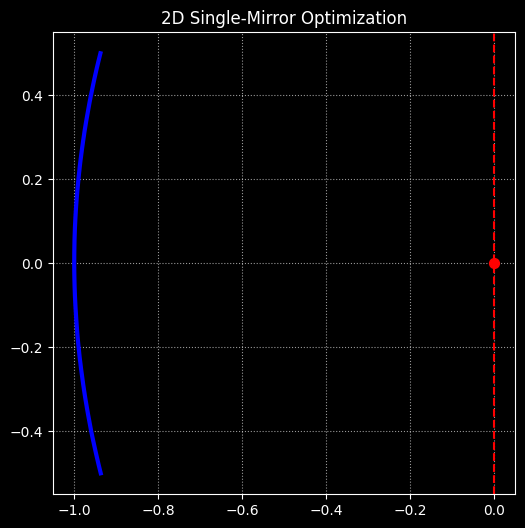

In [187]:
# Create the figure
fig = plt.figure(figsize=(10, 6))

# Draw the mirror by connecting the vertices
plt.plot(sorted_final_x, sorted_final_y, 'b-', lw=3, label='Optimized Mirror')

# Draw the target plane and centre
plt.axvline(x=0, color='red', linestyle='--', label='Target Plane (x=0)')
plt.scatter([0], [target_center.y], color='red', s=50, zorder=5, label='Target Centre')

# Labels and formatting
plt.title('2D Single-Mirror Optimization')
plt.grid(True, linestyle=':', alpha=0.6)
plt.gca().set_aspect('equal', adjustable='box')

# Save
write_figure(fig, output_path, 'optimized_mirror')

# Display
plt.show()

# Mean Ray Test

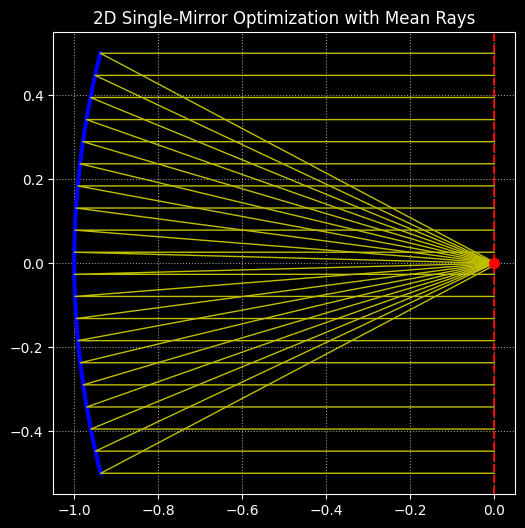

In [188]:
# Compute some mean rays
# TODO: Clean this up. A lot.
test_ray_ys = dr.linspace(mi.Float, sorted_final_y[0] + epsilon, sorted_final_y[-1] - epsilon, test_mean_rays)
test_ray_dir = mi.Vector3f(-1, 0, 0)
test_ray_origins = mi.Point3f(-0.0, test_ray_ys, 0.0)
test_rays = mi.Ray3f(o=test_ray_origins, d=test_ray_dir)
test_si = scene.ray_intersect(test_rays)
test_wo = test_rays.d - 2 * dr.dot(test_rays.d, test_si.n) * test_si.n
test_reflected_rays = test_si.spawn_ray(test_wo)
test_si2 = scene.ray_intersect(test_reflected_rays)
test_x0 = np.array(test_ray_origins)[0]
test_y0 = np.array(test_ray_origins)[1]
test_x1 = np.array(test_si.p.x)
test_y1 = np.array(test_si.p.y)
test_x2 = np.array(test_si2.p.x)
test_y2 = np.array(test_si2.p.y)
mean_x = [list(x) for x in zip(*[test_x0, test_x1, test_x2])]
mean_y = [list(y) for y in zip(*[test_y0, test_y1, test_y2])]

# Create the figure
fig = plt.figure(figsize=(10, 6))

# Draw the mirror by connecting the vertices
plt.plot(sorted_final_x, sorted_final_y, 'b-', lw=3, label='Optimized Mirror')

# Draw the target plane and centre
plt.axvline(x=0, color='red', linestyle='--', label='Target Plane (x=0)')
plt.scatter([0], [target_center.y], color='red', s=50, zorder=5, label='Target Centre')

# Labels and formatting
plt.title('2D Single-Mirror Optimization with Mean Rays')
plt.grid(True, linestyle=':', alpha=0.6)
plt.gca().set_aspect('equal', adjustable='box')

# Plot the mean rays
for i in range(len(mean_x)):
    plt.plot(mean_x[i], mean_y[i], 'y-', lw=1, label='Mean Rays')

# Save
write_figure(fig, output_path, 'optimized_mirror_with_mean_rays')

# Display
plt.show()

# Final Scene

In [189]:
final_scene_image = mi.render(scene, sensor=scene_camera, spp=100)
write_render(final_scene_image, output_path, "scene_render")
mi.util.convert_to_bitmap(final_scene_image)

Bitmap[
  pixel_format = rgb,
  component_format = uint8,
  size = [768, 576],
  srgb_gamma = 1,
  struct = Struct<3>[
    uint8 R; // @0, normalized, gamma, premultiplied alpha
    uint8 G; // @1, normalized, gamma, premultiplied alpha
    uint8 B; // @2, normalized, gamma, premultiplied alpha
  ],
  data = [ 1.27 MiB of image data ]
]

# Final Target

In [190]:
# Make the mirror a true mirror
# This only matters if you want to render the scene with mitsuba, which isn't strictly necessary as we plot with matplotlib later, but leaving it in for interest
# The "true ideal" mirror is also provided, but given probabilities, is vanishingly unlikely to hit anything
ideal_mirror_bsdf = mi.load_dict({
    'type': 'conductor',
    'material': 'none'
})
mirror_bsdf = mi.load_dict({
    'type': 'roughconductor',
    'alpha': mirror_rough_conductor_alpha,
})
mirror1_mesh.set_bsdf(ideal_mirror_bsdf)
# mirror1_mesh.set_bsdf(mirror_bsdf)

final_target_image = mi.render(scene, sensor=target_camera, spp=4000)
write_render(final_target_image, output_path, "target_render")
mi.util.convert_to_bitmap(final_target_image)

Bitmap[
  pixel_format = rgb,
  component_format = uint8,
  size = [256, 256],
  srgb_gamma = 1,
  struct = Struct<3>[
    uint8 R; // @0, normalized, gamma, premultiplied alpha
    uint8 G; // @1, normalized, gamma, premultiplied alpha
    uint8 B; // @2, normalized, gamma, premultiplied alpha
  ],
  data = [ 192 KiB of image data ]
]